In [1]:
import tensorflow as tf

from keras.datasets import reuters
(train_data, train_labels), (test_data, test_labels) = reuters.load_data(
num_words=10000)

2110848/2110848 [==============================] - 1s 0us/step


In [2]:
len(train_data)

8982

In [3]:
len(test_data)

2246

In [6]:
train_data(1)

TypeError: 'numpy.ndarray' object is not callable

In [5]:
import numpy as np

In [8]:
def vectorize_sequences(sequences, dimension=10000):
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1.
    return results

x_train = vectorize_sequences(train_data)
x_test = vectorize_sequences(test_data)


In [9]:
from keras.utils.np_utils import to_categorical
one_hot_train_labels = to_categorical(train_labels)
one_hot_test_labels = to_categorical(test_labels)

In [10]:
from keras import models
from keras import layers

model = models.Sequential()
model.add(layers.Dense(64, activation='relu', input_shape=(10000,)))
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(46, activation='softmax'))

In [11]:
model.compile(optimizer='rmsprop',
            loss='categorical_crossentropy',
            metrics=['accuracy'])

In [13]:
x_val = x_train[:1000]
partial_x_train = x_train[1000:]

y_val = one_hot_train_labels[:1000]
partial_y_train = one_hot_train_labels[1000:]
                                       
history = model.fit(partial_x_train,
                    partial_y_train,
                    epochs=20,
                    batch_size=512,
                    validation_data=(x_val, y_val))

Epoch 1/20
16/16 [==============================] - 1s 23ms/step - loss: 2.7212 - accuracy: 0.5091 - val_loss: 1.8464 - val_accuracy: 0.6260
Epoch 2/20
16/16 [==============================] - 0s 14ms/step - loss: 1.5355 - accuracy: 0.6847 - val_loss: 1.3840 - val_accuracy: 0.6940
Epoch 3/20
16/16 [==============================] - 0s 14ms/step - loss: 1.1766 - accuracy: 0.7474 - val_loss: 1.1738 - val_accuracy: 0.7460
Epoch 4/20
16/16 [==============================] - 0s 14ms/step - loss: 0.9598 - accuracy: 0.7969 - val_loss: 1.0832 - val_accuracy: 0.7600
Epoch 5/20
16/16 [==============================] - 0s 14ms/step - loss: 0.7987 - accuracy: 0.8297 - val_loss: 0.9875 - val_accuracy: 0.7870
Epoch 6/20
16/16 [==============================] - 0s 14ms/step - loss: 0.6652 - accuracy: 0.8582 - val_loss: 0.9409 - val_accuracy: 0.7960
Epoch 7/20
16/16 [==============================] - 0s 14ms/step - loss: 0.5527 - accuracy: 0.8859 - val_loss: 0.9132 - val_accuracy: 0.7980
Epoch 8/20
16

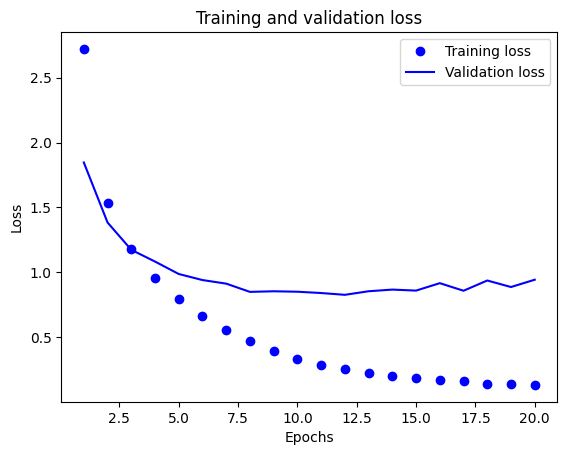

In [14]:
import matplotlib.pyplot as plt

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(loss) + 1)

plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [15]:
plt.clf()

acc = history.history['acc']
val_acc = history.history['val_acc']

plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

KeyError: 'acc'

<Figure size 640x480 with 0 Axes>